# Analyse des tendances et recommandation de lancement produit

Ce notebook est concu pour:
- charger le dataset Kaggle,
- identifier les colonnes utiles automatiquement,
- mettre en avant les tendances business,
- produire un ranking des produits a privilegier pour un futur lancement.

In [1]:
# Installation (si necessaire)
%pip install -q kagglehub[pandas-datasets] pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\pauli\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

## 1) Chargement des donnees

In [3]:
DATASET = "arfeenkabir/customer-purchase-behavior-analysis"

# Si tu connais le fichier exact (csv/parquet), mets son nom ici, sinon laisse vide.
file_path = ""

if file_path:
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        DATASET,
        file_path,
    )
else:
    local_path = Path(kagglehub.dataset_download(DATASET))
    candidates = list(local_path.rglob("*.csv")) + list(local_path.rglob("*.parquet"))
    if not candidates:
        raise FileNotFoundError("Aucun CSV/Parquet trouve dans le dataset telecharge.")
    selected = max(candidates, key=lambda p: p.stat().st_size)
    print(f"Fichier selectionne automatiquement: {selected.name}")
    if selected.suffix.lower() == ".csv":
        df = pd.read_csv(selected)
    else:
        df = pd.read_parquet(selected)

print("Shape:", df.shape)
display(df.head(10))

Fichier selectionne automatiquement: shopping_trends.csv
Shape: (3900, 19)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Venmo,Standard,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Debit Card,Free Shipping,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Debit Card,Free Shipping,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Venmo,Express,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,PayPal,2-Day Shipping,Yes,Yes,4,Cash,Quarterly


## 2) Detection automatique des colonnes analytiques

In [4]:
def find_col(df, keywords):
    cols = {c.lower(): c for c in df.columns}
    for k in keywords:
        exact = [orig for low, orig in cols.items() if low == k]
        if exact:
            return exact[0]
    for k in keywords:
        partial = [orig for low, orig in cols.items() if k in low]
        if partial:
            return partial[0]
    return None

date_col = find_col(df, ["date", "order_date", "purchase_date", "transaction_date", "timestamp"])
product_col = find_col(df, ["product", "item", "sku", "category", "product_name"])
customer_col = find_col(df, ["customer_id", "customer", "client_id", "user_id"])
revenue_col = find_col(df, ["revenue", "sales", "amount", "total", "total_amount", "price"])
quantity_col = find_col(df, ["quantity", "qty", "units", "unit_sold"])

print("Colonnes detectees:")
print({
    "date_col": date_col,
    "product_col": product_col,
    "customer_col": customer_col,
    "revenue_col": revenue_col,
    "quantity_col": quantity_col,
})

Colonnes detectees:
{'date_col': None, 'product_col': 'Category', 'customer_col': 'Customer ID', 'revenue_col': 'Purchase Amount (USD)', 'quantity_col': None}


In [5]:
# Preparation des champs robustes pour l'analyse
work = df.copy()

if date_col is not None:
    work["_date"] = pd.to_datetime(work[date_col], errors="coerce")
else:
    work["_date"] = pd.NaT

if product_col is not None:
    work["_product"] = work[product_col].astype(str)
else:
    work["_product"] = "ALL_PRODUCTS"

if customer_col is not None:
    work["_customer"] = work[customer_col].astype(str)
else:
    work["_customer"] = np.arange(len(work)).astype(str)

if revenue_col is not None:
    work["_revenue"] = pd.to_numeric(work[revenue_col], errors="coerce").fillna(0)
elif quantity_col is not None:
    work["_revenue"] = pd.to_numeric(work[quantity_col], errors="coerce").fillna(0)
else:
    work["_revenue"] = 1.0

if quantity_col is not None:
    work["_qty"] = pd.to_numeric(work[quantity_col], errors="coerce").fillna(1)
else:
    work["_qty"] = 1

display(work[["_date", "_product", "_customer", "_revenue", "_qty"]].head())

,_date,_product,_customer,_revenue,_qty
0,NaT,Clothing,1,53,1
1,NaT,Clothing,2,64,1
2,NaT,Clothing,3,73,1
3,NaT,Footwear,4,90,1
4,NaT,Clothing,5,49,1


## 3) KPI business pertinents a monitorer

In [6]:
kpi = {
    "transactions": int(len(work)),
    "clients_uniques": int(work["_customer"].nunique()),
    "produits_uniques": int(work["_product"].nunique()),
    "revenu_total": float(work["_revenue"].sum()),
    "revenu_moyen_par_transaction": float(work["_revenue"].mean()),
}

pd.DataFrame([kpi]).T.rename(columns={0: "value"})

,value
transactions,3900.000000
clients_uniques,3900.000000
produits_uniques,4.000000
revenu_total,233081.000000
revenu_moyen_par_transaction,59.764359


,_product,revenu,quantite,transactions,clients_uniques
1,Clothing,104264,1737,1737,1737
0,Accessories,74200,1240,1240,1240
2,Footwear,36093,599,599,599
3,Outerwear,18524,324,324,324


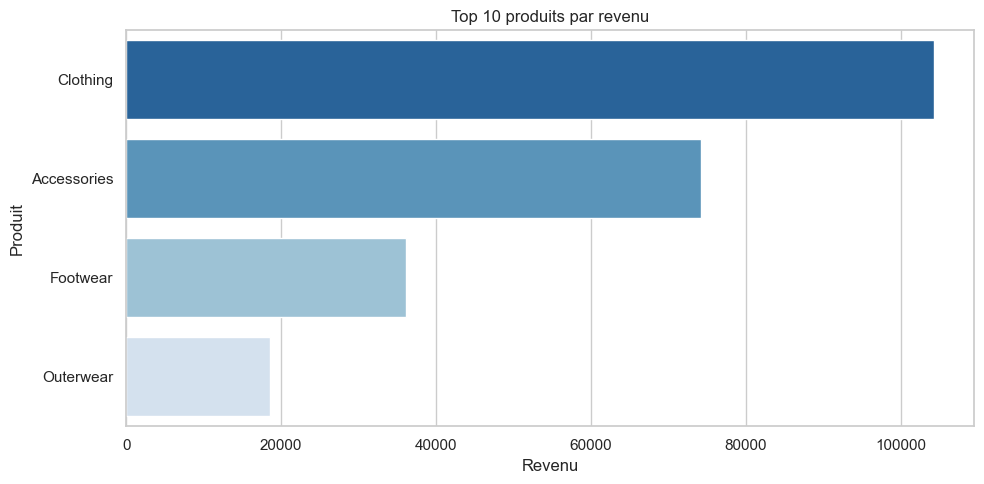

In [7]:
# Top produits par revenu et volume
product_perf = (
    work.groupby("_product", as_index=False)
    .agg(
        revenu=("_revenue", "sum"),
        quantite=("_qty", "sum"),
        transactions=("_product", "size"),
        clients_uniques=("_customer", "nunique"),
    )
    .sort_values("revenu", ascending=False)
)

display(product_perf.head(15))

plt.figure(figsize=(10, 5))
sns.barplot(data=product_perf.head(10), x="revenu", y="_product", palette="Blues_r")
plt.title("Top 10 produits par revenu")
plt.xlabel("Revenu")
plt.ylabel("Produit")
plt.tight_layout()
plt.show()

In [8]:
# Tendances temporelles (si date disponible)
if work["_date"].notna().sum() > 0:
    time_df = work.dropna(subset=["_date"]).copy()
    time_df["year_month"] = time_df["_date"].dt.to_period("M").astype(str)

    monthly = (
        time_df.groupby("year_month", as_index=False)
        .agg(revenu=("_revenue", "sum"), transactions=("_product", "size"))
        .sort_values("year_month")
    )
    display(monthly.tail(12))

    fig, ax1 = plt.subplots(figsize=(12, 5))
    sns.lineplot(data=monthly, x="year_month", y="revenu", marker="o", ax=ax1)
    ax1.set_title("Evolution mensuelle du revenu")
    ax1.set_xlabel("Mois")
    ax1.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Pas de colonne date exploitable: analyse de tendance temporelle ignoree.")

Pas de colonne date exploitable: analyse de tendance temporelle ignoree.


## 4) Ranking d'opportunite pour futur lancement

Logique du score (0 a 100):
- 35% traction actuelle (revenu)
- 25% base clients (clients uniques)
- 25% dynamique recente (croissance 3 derniers mois vs 3 mois precedents, si date)
- 15% repetition (transactions / clients uniques)

In [9]:
opportunity = product_perf.copy()

# Repetition
opportunity["repeat_ratio"] = opportunity["transactions"] / opportunity["clients_uniques"].replace(0, np.nan)
opportunity["repeat_ratio"] = opportunity["repeat_ratio"].fillna(0)

# Croissance recente
opportunity["recent_growth"] = 0.0
if work["_date"].notna().sum() > 0:
    t = work.dropna(subset=["_date"]).copy()
    t["period"] = t["_date"].dt.to_period("M")
    max_period = t["period"].max()
    recent_periods = [max_period - i for i in range(0, 3)]
    prev_periods = [max_period - i for i in range(3, 6)]

    recent = t[t["period"].isin(recent_periods)].groupby("_product")["_revenue"].sum()
    prev = t[t["period"].isin(prev_periods)].groupby("_product")["_revenue"].sum()

    growth = ((recent - prev) / prev.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0)
    opportunity = opportunity.merge(growth.rename("recent_growth"), on="_product", how="left", suffixes=("", "_new"))
    if "recent_growth_new" in opportunity.columns:
        opportunity["recent_growth"] = opportunity["recent_growth_new"].fillna(0)
        opportunity = opportunity.drop(columns=["recent_growth_new"])

def minmax(s):
    s = s.astype(float)
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

opportunity["score_traction"] = minmax(opportunity["revenu"])
opportunity["score_clients"] = minmax(opportunity["clients_uniques"])
opportunity["score_growth"] = minmax(opportunity["recent_growth"])
opportunity["score_repeat"] = minmax(opportunity["repeat_ratio"])

opportunity["opportunity_score"] = (
    0.35 * opportunity["score_traction"]
    + 0.25 * opportunity["score_clients"]
    + 0.25 * opportunity["score_growth"]
    + 0.15 * opportunity["score_repeat"]
) * 100

opportunity = opportunity.sort_values("opportunity_score", ascending=False)

cols = [
    "_product", "opportunity_score", "revenu", "clients_uniques", "transactions",
    "recent_growth", "repeat_ratio"
]
display(opportunity[cols].head(15).round(3))

,_product,opportunity_score,revenu,clients_uniques,transactions,recent_growth,repeat_ratio
1,Clothing,60.000,104264,1737,1737,0.0,1.0
0,Accessories,38.934,74200,1240,1240,0.0,1.0
2,Footwear,12.037,36093,599,599,0.0,1.0
3,Outerwear,0.000,18524,324,324,0.0,1.0


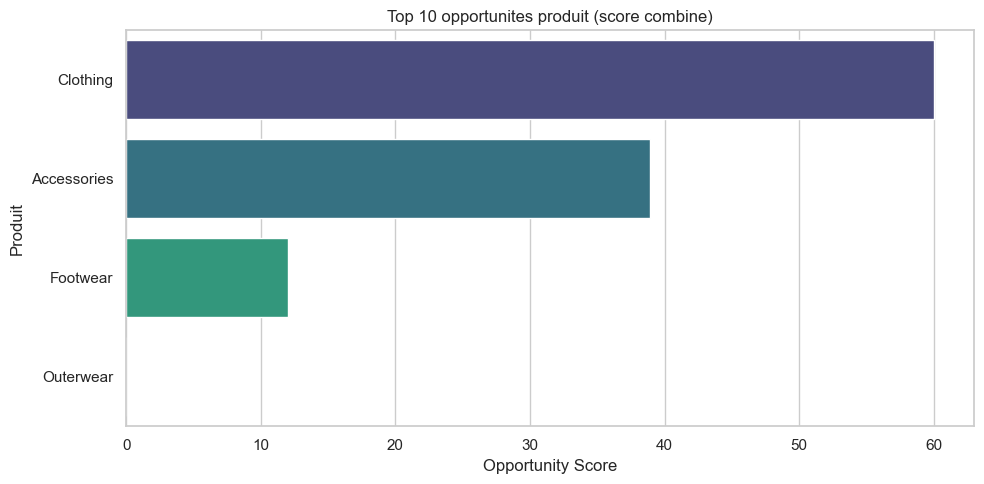

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(data=opportunity.head(10), x="opportunity_score", y="_product", palette="viridis")
plt.title("Top 10 opportunites produit (score combine)")
plt.xlabel("Opportunity Score")
plt.ylabel("Produit")
plt.tight_layout()
plt.show()

## 5) Interpretation business (a completer apres execution)

Utilise ces points pour ta decision finale:
- **Produit a lancer en priorite**: top 1 du `opportunity_score`.
- **Produits a surveiller**: ceux avec forte `recent_growth` mais revenu encore moyen (potentiel de scale).
- **Produits defensifs**: fort revenu mais croissance faible (cash-cows).
- **Prochaines actions recommandees**:
  1. tester une extension de gamme proche du top produit,
  2. valider la demande par campagne pilote,
  3. ajuster prix/offre selon repeat_ratio et segmentation client.

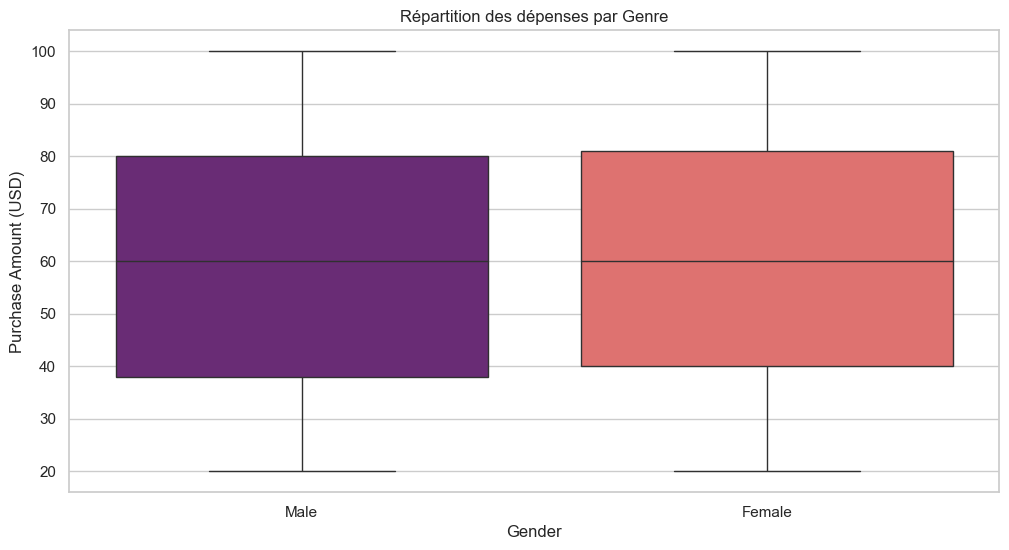

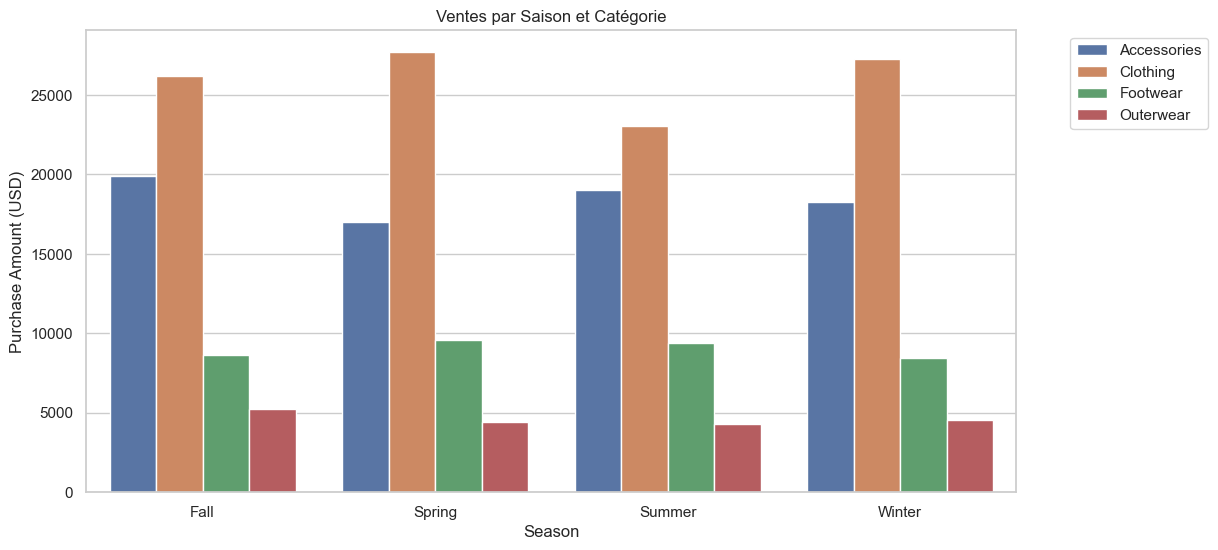

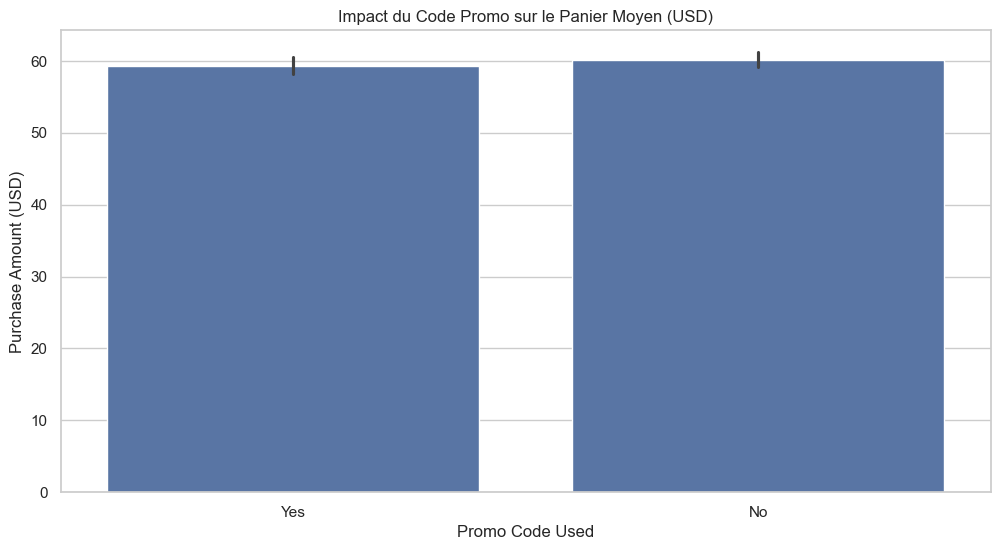

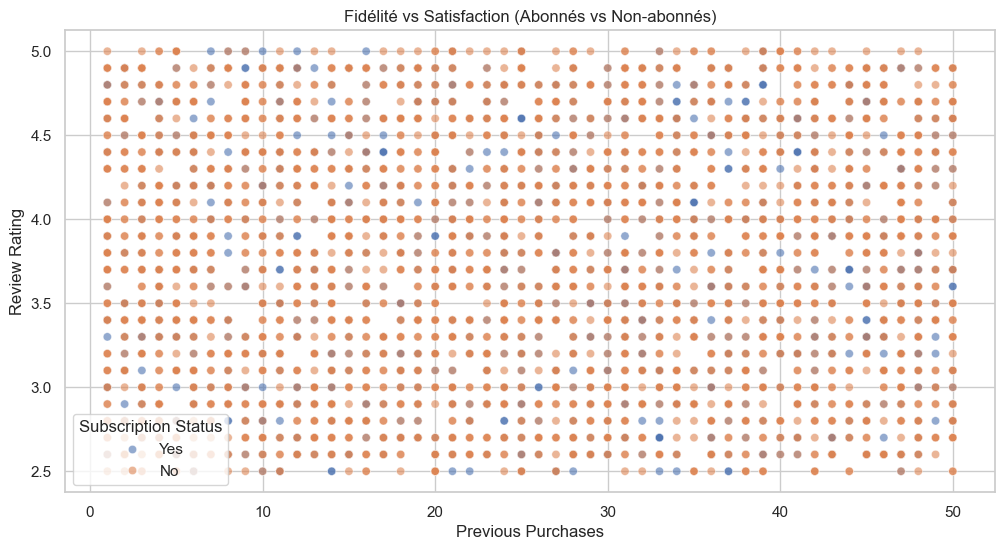

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration visuelle
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# 1. SEGMENTATION PAR ÂGE ET GENRE (Dépenses totales)
plt.figure()
sns.boxplot(data=df, x='Gender', y='Purchase Amount (USD)', palette='magma')
plt.title('Répartition des dépenses par Genre')
plt.show()

# 2. TOP CATÉGORIES PAR SAISON
plt.figure()
seasonal_sales = df.groupby(['Season', 'Category'])['Purchase Amount (USD)'].sum().reset_index()
sns.barplot(data=seasonal_sales, x='Season', y='Purchase Amount (USD)', hue='Category')
plt.title('Ventes par Saison et Catégorie')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 3. IMPACT DES CODES PROMO SUR LE PANIER MOYEN
plt.figure()
sns.barplot(data=df, x='Promo Code Used', y='Purchase Amount (USD)', estimator='mean')
plt.title('Impact du Code Promo sur le Panier Moyen (USD)')
plt.show()

# 4. ANALYSE DE LA FIDÉLITÉ (Previous Purchases vs Review Rating)
plt.figure()
sns.scatterplot(data=df, x='Previous Purchases', y='Review Rating', hue='Subscription Status', alpha=0.6)
plt.title('Fidélité vs Satisfaction (Abonnés vs Non-abonnés)')
plt.show()

## 6) Deep dive categorie Clothing

Objectif:
- identifier quelle cible (genre x taille) achete le plus,
- comprendre quels items sont les plus achetes dans Clothing,
- produire une recommandation cible + offre produit.

In [12]:
# Colonnes attendues dans ce dataset
category_c = "Category"
item_c = "Item Purchased"
gender_c = "Gender"
size_c = "Size"
amount_c = "Purchase Amount (USD)"
customer_c = "Customer ID"

required = [category_c, item_c, gender_c, size_c, amount_c]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes pour le deep dive Clothing: {missing}")

cloth = df[df[category_c].astype(str).str.lower() == "clothing"].copy()
cloth[amount_c] = pd.to_numeric(cloth[amount_c], errors="coerce").fillna(0)
cloth[item_c] = cloth[item_c].astype(str)
cloth[gender_c] = cloth[gender_c].astype(str)
cloth[size_c] = cloth[size_c].astype(str)

print(f"Transactions Clothing: {len(cloth):,}")
print(f"CA Clothing (USD): {cloth[amount_c].sum():,.2f}")
display(cloth[[item_c, gender_c, size_c, amount_c]].head())

Transactions Clothing: 1,737
CA Clothing (USD): 104,264.00


,Item Purchased,Gender,Size,Purchase Amount (USD)
0,Blouse,Male,L,53
1,Sweater,Male,L,64
2,Jeans,Male,S,73
4,Blouse,Male,M,49
6,Shirt,Male,M,85


,Item Purchased,transactions,revenue,avg_basket
0,Blouse,171,10410,60.88
4,Pants,171,10090,59.01
5,Shirt,169,10332,61.14
1,Dress,166,10320,62.17
9,Sweater,164,9462,57.70
8,Socks,159,9252,58.19
7,Skirt,158,9402,59.51
6,Shorts,157,9433,60.08
2,Hoodie,151,8767,58.06
10,T-shirt,147,9248,62.91


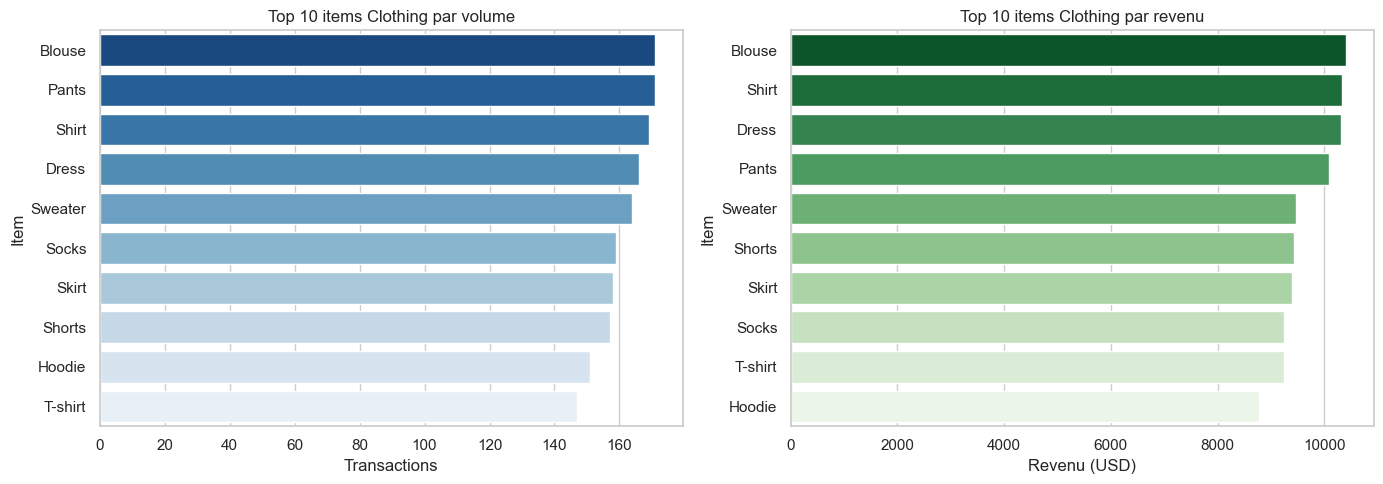

In [13]:
# 1) Items Clothing les plus achetes (volume + revenu)
item_stats = (
    cloth.groupby(item_c, as_index=False)
    .agg(
        transactions=(item_c, "size"),
        revenue=(amount_c, "sum"),
        avg_basket=(amount_c, "mean"),
    )
    .sort_values(["transactions", "revenue"], ascending=False)
)

display(item_stats.head(12).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=item_stats.head(10), x="transactions", y=item_c, palette="Blues_r", ax=axes[0])
axes[0].set_title("Top 10 items Clothing par volume")
axes[0].set_xlabel("Transactions")
axes[0].set_ylabel("Item")

sns.barplot(data=item_stats.sort_values("revenue", ascending=False).head(10), x="revenue", y=item_c, palette="Greens_r", ax=axes[1])
axes[1].set_title("Top 10 items Clothing par revenu")
axes[1].set_xlabel("Revenu (USD)")
axes[1].set_ylabel("Item")

plt.tight_layout()
plt.show()

,Gender,Size,transactions,revenue,avg_basket,unique_customers
5,Male,M,510,30716,60.23,510
4,Male,L,328,18977,57.86,328
1,Female,M,268,16325,60.91,268
6,Male,S,207,12428,60.04,207
0,Female,L,153,8887,58.08,153
7,Male,XL,136,8507,62.55,136
2,Female,S,77,4988,64.78,77
3,Female,XL,58,3436,59.24,58


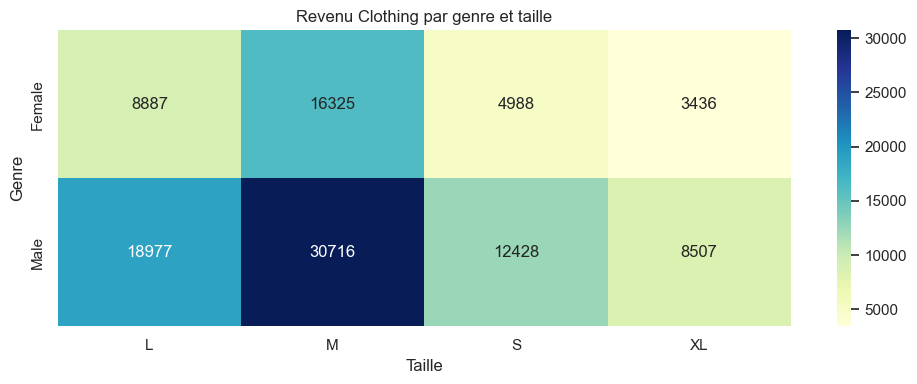

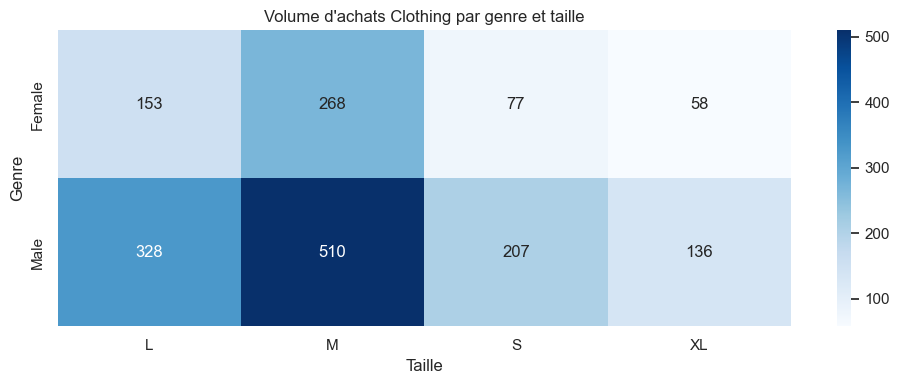

In [14]:
# 2) Quelle cible achete le plus ? (genre x taille)
segment_stats = (
    cloth.groupby([gender_c, size_c], as_index=False)
    .agg(
        transactions=(item_c, "size"),
        revenue=(amount_c, "sum"),
        avg_basket=(amount_c, "mean"),
        unique_customers=(customer_c, "nunique") if customer_c in cloth.columns else (item_c, "size"),
    )
    .sort_values("revenue", ascending=False)
)

display(segment_stats.head(15).round(2))

# Heatmap revenu par segment
pivot_rev = cloth.pivot_table(index=gender_c, columns=size_c, values=amount_c, aggfunc="sum", fill_value=0)
plt.figure(figsize=(10, 4))
sns.heatmap(pivot_rev, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Revenu Clothing par genre et taille")
plt.xlabel("Taille")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

# Heatmap volume par segment
pivot_vol = cloth.pivot_table(index=gender_c, columns=size_c, values=item_c, aggfunc="count", fill_value=0)
plt.figure(figsize=(10, 4))
sns.heatmap(pivot_vol, annot=True, fmt=".0f", cmap="Blues")
plt.title("Volume d'achats Clothing par genre et taille")
plt.xlabel("Taille")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

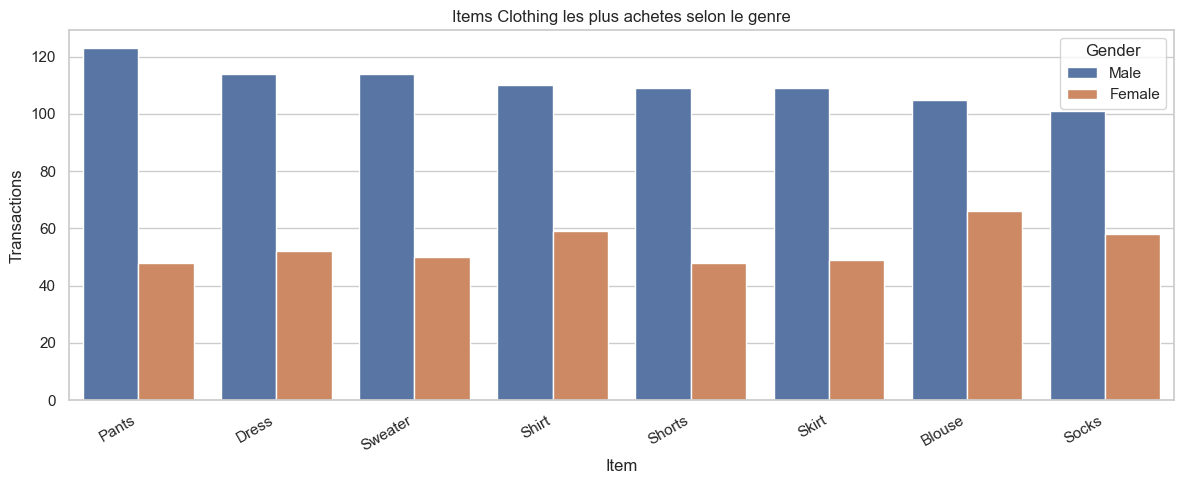

,Gender,Size,Item Purchased,transactions,revenue
5,Male,M,Pants,65,3840
4,Male,L,Skirt,35,1908
1,Female,M,Socks,31,1766
6,Male,S,Skirt,23,1313
0,Female,L,Blouse,21,1219
7,Male,XL,Shirt,16,1197
2,Female,S,Sweater,13,775
3,Female,XL,Socks,9,445



=== Recommandation cible Clothing ===
Cible la plus active: Male - Taille M
Transactions: 510 | Revenu: $30716.00
Top achats de cette cible:


,Item Purchased,transactions,revenue
4,Pants,65,3840
5,Shirt,56,3353
9,Sweater,53,2865
1,Dress,51,3052
0,Blouse,46,2714
6,Shorts,46,2654
2,Hoodie,44,2685
8,Socks,43,2657
7,Skirt,41,2623
10,T-shirt,39,2596


In [15]:
# 3) Que chaque cible achete-t-elle ? (item x genre) + top cible
# Cellule autonome: reconstruit les objets si les cellules precedentes n'ont pas ete executees.
if "item_c" not in globals():
    item_c = "Item Purchased"
if "gender_c" not in globals():
    gender_c = "Gender"
if "size_c" not in globals():
    size_c = "Size"
if "amount_c" not in globals():
    amount_c = "Purchase Amount (USD)"
if "category_c" not in globals():
    category_c = "Category"
if "customer_c" not in globals():
    customer_c = "Customer ID"

if "cloth" not in globals():
    if category_c not in df.columns:
        raise ValueError(f"Colonne '{category_c}' introuvable dans df.")
    cloth = df[df[category_c].astype(str).str.lower() == "clothing"].copy()
    cloth[amount_c] = pd.to_numeric(cloth[amount_c], errors="coerce").fillna(0)
    cloth[item_c] = cloth[item_c].astype(str)
    cloth[gender_c] = cloth[gender_c].astype(str)
    cloth[size_c] = cloth[size_c].astype(str)

if "item_stats" not in globals():
    item_stats = (
        cloth.groupby(item_c, as_index=False)
        .agg(
            transactions=(item_c, "size"),
            revenue=(amount_c, "sum"),
            avg_basket=(amount_c, "mean"),
        )
        .sort_values(["transactions", "revenue"], ascending=False)
    )

if "segment_stats" not in globals():
    segment_stats = (
        cloth.groupby([gender_c, size_c], as_index=False)
        .agg(
            transactions=(item_c, "size"),
            revenue=(amount_c, "sum"),
            avg_basket=(amount_c, "mean"),
            unique_customers=(customer_c, "nunique") if customer_c in cloth.columns else (item_c, "size"),
        )
        .sort_values("revenue", ascending=False)
    )

item_gender = (
    cloth.groupby([gender_c, item_c], as_index=False)
    .agg(transactions=(item_c, "size"), revenue=(amount_c, "sum"))
)

# Garder les items les plus importants pour la lisibilite
keep_items = item_stats.head(8)[item_c].tolist()
plot_df = item_gender[item_gender[item_c].isin(keep_items)].copy()

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df.sort_values("transactions", ascending=False), x=item_c, y="transactions", hue=gender_c)
plt.title("Items Clothing les plus achetes selon le genre")
plt.xlabel("Item")
plt.ylabel("Transactions")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Item dominant dans chaque segment genre x taille
seg_item = (
    cloth.groupby([gender_c, size_c, item_c], as_index=False)
    .agg(transactions=(item_c, "size"), revenue=(amount_c, "sum"))
)
seg_top_item = seg_item.sort_values([gender_c, size_c, "transactions", "revenue"], ascending=[True, True, False, False]).groupby([gender_c, size_c], as_index=False).first()

display(seg_top_item.sort_values(["transactions", "revenue"], ascending=False).head(20))

# Cible la plus forte (par revenu puis volume)
best_target = segment_stats.sort_values(["revenue", "transactions"], ascending=False).head(1)
best_gender = best_target.iloc[0][gender_c]
best_size = best_target.iloc[0][size_c]

target_items = (
    cloth[(cloth[gender_c] == best_gender) & (cloth[size_c] == best_size)]
    .groupby(item_c, as_index=False)
    .agg(transactions=(item_c, "size"), revenue=(amount_c, "sum"))
    .sort_values(["transactions", "revenue"], ascending=False)
)

print("\n=== Recommandation cible Clothing ===")
print(f"Cible la plus active: {best_gender} - Taille {best_size}")
print(f"Transactions: {int(best_target.iloc[0]['transactions'])} | Revenu: ${best_target.iloc[0]['revenue']:.2f}")
print("Top achats de cette cible:")
display(target_items.head(10))

## 7) Focus couleur: preferences d'achat des hommes (et hommes taille M)

Objectif:
- identifier les couleurs preferees par les hommes,
- verifier si les preferences changent pour la cible prioritaire Homme taille M,
- en deduire des recommandations produit (coloris a lancer en priorite).

In [16]:
# Cellule autonome pour l'analyse couleur
if "item_c" not in globals():
    item_c = "Item Purchased"
if "gender_c" not in globals():
    gender_c = "Gender"
if "size_c" not in globals():
    size_c = "Size"
if "amount_c" not in globals():
    amount_c = "Purchase Amount (USD)"
if "category_c" not in globals():
    category_c = "Category"

color_c = "Color"
required_cols = [category_c, gender_c, size_c, item_c, amount_c, color_c]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Colonnes manquantes pour l'analyse couleur: {missing_cols}")

if "cloth" not in globals():
    cloth = df[df[category_c].astype(str).str.lower() == "clothing"].copy()
    cloth[amount_c] = pd.to_numeric(cloth[amount_c], errors="coerce").fillna(0)

# Normaliser les champs utiles
cloth[color_c] = cloth[color_c].astype(str)
cloth[gender_c] = cloth[gender_c].astype(str)
cloth[size_c] = cloth[size_c].astype(str)
cloth[item_c] = cloth[item_c].astype(str)

men_cloth = cloth[cloth[gender_c].str.lower() == "male"].copy()
men_m_cloth = men_cloth[men_cloth[size_c].str.upper() == "M"].copy()

print(f"Transactions Clothing - Hommes: {len(men_cloth):,}")
print(f"Transactions Clothing - Hommes taille M: {len(men_m_cloth):,}")

Transactions Clothing - Hommes: 1,181
Transactions Clothing - Hommes taille M: 510


,Color,transactions,revenue,avg_basket
8,Green,57,3943,69.18
20,Teal,57,3514,61.65
22,Violet,56,3622,64.68
12,Maroon,55,3513,63.87
19,Silver,54,2902,53.74
5,Cyan,53,3109,58.66
14,Orange,50,3218,64.36
17,Purple,50,2891,57.82
4,Charcoal,49,2885,58.88
0,Beige,48,2994,62.38


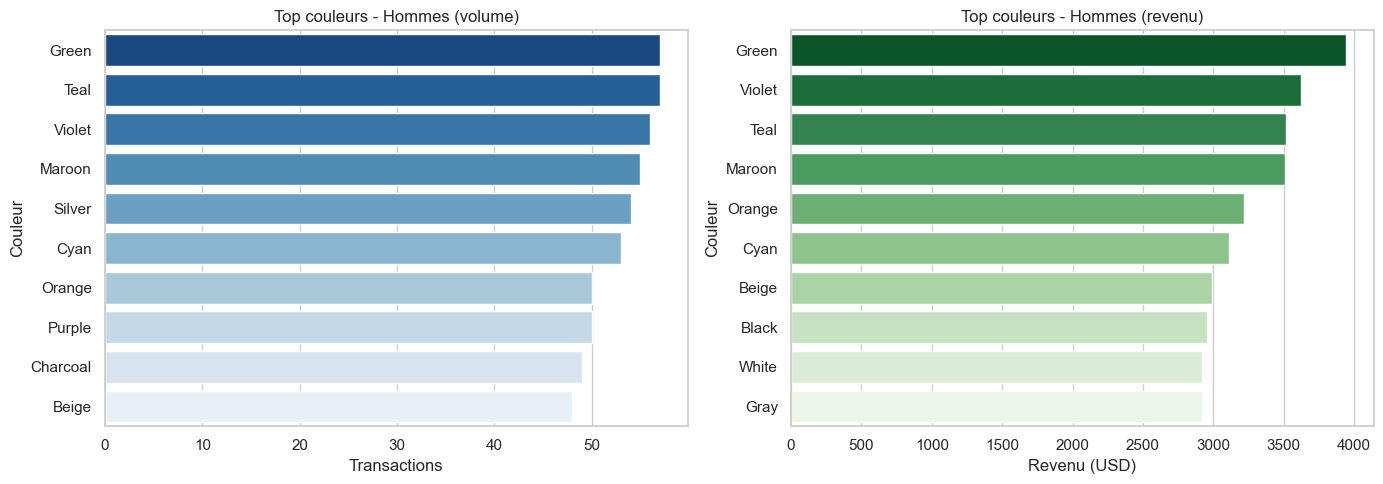

In [17]:
# 1) Quelles couleurs les hommes achetent le plus ?
men_color_stats = (
    men_cloth.groupby(color_c, as_index=False)
    .agg(
        transactions=(color_c, "size"),
        revenue=(amount_c, "sum"),
        avg_basket=(amount_c, "mean"),
    )
    .sort_values(["transactions", "revenue"], ascending=False)
)

display(men_color_stats.head(12).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=men_color_stats.head(10), x="transactions", y=color_c, palette="Blues_r", ax=axes[0])
axes[0].set_title("Top couleurs - Hommes (volume)")
axes[0].set_xlabel("Transactions")
axes[0].set_ylabel("Couleur")

sns.barplot(data=men_color_stats.sort_values("revenue", ascending=False).head(10), x="revenue", y=color_c, palette="Greens_r", ax=axes[1])
axes[1].set_title("Top couleurs - Hommes (revenu)")
axes[1].set_xlabel("Revenu (USD)")
axes[1].set_ylabel("Couleur")

plt.tight_layout()
plt.show()

In [18]:
# 3 bis) Synthese robuste (execute meme si les cellules precedentes n'ont pas tourne)
if "item_c" not in globals():
    item_c = "Item Purchased"
if "gender_c" not in globals():
    gender_c = "Gender"
if "size_c" not in globals():
    size_c = "Size"
if "amount_c" not in globals():
    amount_c = "Purchase Amount (USD)"
if "category_c" not in globals():
    category_c = "Category"
if "color_c" not in globals():
    color_c = "Color"

required_cols = [category_c, gender_c, size_c, item_c, amount_c, color_c]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Colonnes manquantes pour la synthese couleur: {missing_cols}")

if "cloth" not in globals():
    cloth = df[df[category_c].astype(str).str.lower() == "clothing"].copy()
    cloth[amount_c] = pd.to_numeric(cloth[amount_c], errors="coerce").fillna(0)
    cloth[color_c] = cloth[color_c].astype(str)
    cloth[gender_c] = cloth[gender_c].astype(str)
    cloth[size_c] = cloth[size_c].astype(str)
    cloth[item_c] = cloth[item_c].astype(str)

men_cloth = cloth[cloth[gender_c].str.lower() == "male"].copy()
men_m_cloth = men_cloth[men_cloth[size_c].str.upper() == "M"].copy()

men_color_stats = (
    men_cloth.groupby(color_c, as_index=False)
    .agg(transactions=(color_c, "size"), revenue=(amount_c, "sum"), avg_basket=(amount_c, "mean"))
    .sort_values(["transactions", "revenue"], ascending=False)
)

men_m_color_stats = (
    men_m_cloth.groupby(color_c, as_index=False)
    .agg(transactions=(color_c, "size"), revenue=(amount_c, "sum"))
    .sort_values(["transactions", "revenue"], ascending=False)
)

best_item_color = (
    men_m_cloth.groupby([item_c, color_c], as_index=False)
    .agg(transactions=(item_c, "size"), revenue=(amount_c, "sum"))
    .sort_values(["transactions", "revenue"], ascending=False)
)

top_color_men = men_color_stats.iloc[0][color_c] if len(men_color_stats) else "N/A"
top_color_men_m = men_m_color_stats.iloc[0][color_c] if len(men_m_color_stats) else "N/A"

top_item_m = best_item_color.iloc[0][item_c] if len(best_item_color) else "N/A"
top_item_color_m = best_item_color.iloc[0][color_c] if len(best_item_color) else "N/A"

print("=== Synthese Clothing: cible Homme taille M ===")
print(f"Couleur preferee des hommes (global): {top_color_men}")
print(f"Couleur preferee des hommes taille M: {top_color_men_m}")
print(f"Combinaison item-couleur la plus achetee (Homme M): {top_item_m} / {top_item_color_m}")
print("Recommandation: prioriser un lancement Homme taille M dans les coloris dominants ci-dessus.")

=== Synthese Clothing: cible Homme taille M ===
Couleur preferee des hommes (global): Green
Couleur preferee des hommes taille M: Teal
Combinaison item-couleur la plus achetee (Homme M): Pants / Teal
Recommandation: prioriser un lancement Homme taille M dans les coloris dominants ci-dessus.


,Color,transactions,revenue
20,Teal,29,1626
22,Violet,28,1897
14,Orange,28,1778
15,Peach,28,1743
7,Gray,25,1692
23,White,25,1678
19,Silver,24,1265
8,Green,23,1616
4,Charcoal,23,1465
12,Maroon,23,1392


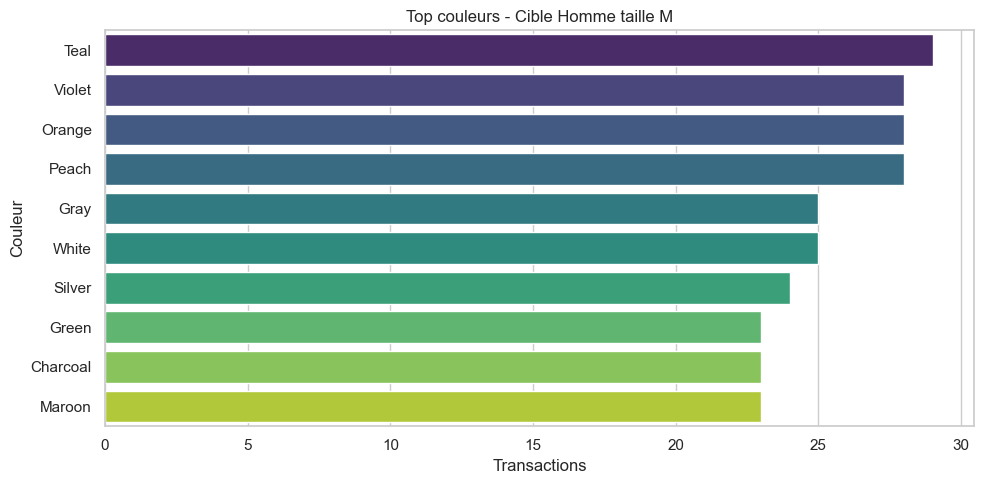

,Item Purchased,Color,transactions,revenue
101,Pants,Teal,8,441
118,Shirt,Orange,7,343
53,Hoodie,Green,6,441
86,Pants,Charcoal,6,388
184,Socks,Red,6,387
62,Hoodie,Silver,6,257
125,Shirt,Violet,5,390
210,Sweater,White,5,338
103,Pants,Violet,5,333
147,Shorts,Violet,5,328


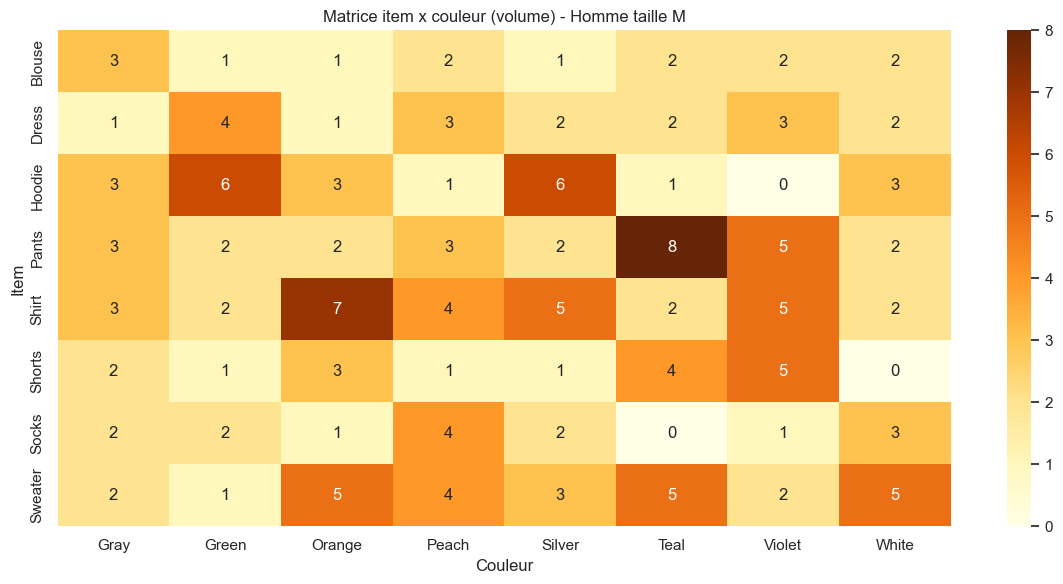

In [19]:
# 2) Pour la cible Homme taille M: quelles couleurs et quels items dominent ?
men_m_color_stats = (
    men_m_cloth.groupby(color_c, as_index=False)
    .agg(
        transactions=(color_c, "size"),
        revenue=(amount_c, "sum"),
    )
    .sort_values(["transactions", "revenue"], ascending=False)
)

display(men_m_color_stats.head(12))

plt.figure(figsize=(10, 5))
sns.barplot(data=men_m_color_stats.head(10), x="transactions", y=color_c, palette="viridis")
plt.title("Top couleurs - Cible Homme taille M")
plt.xlabel("Transactions")
plt.ylabel("Couleur")
plt.tight_layout()
plt.show()

# Item x Couleur pour Homme taille M
men_m_item_color = (
    men_m_cloth.groupby([item_c, color_c], as_index=False)
    .agg(transactions=(item_c, "size"), revenue=(amount_c, "sum"))
)

best_item_color = men_m_item_color.sort_values(["transactions", "revenue"], ascending=False).head(15)
display(best_item_color)

# Heatmap lisible sur les top combinaisons
top_items_m = men_m_cloth[item_c].value_counts().head(8).index
top_colors_m = men_m_cloth[color_c].value_counts().head(8).index
heat_df = men_m_cloth[men_m_cloth[item_c].isin(top_items_m) & men_m_cloth[color_c].isin(top_colors_m)]
heat = heat_df.pivot_table(index=item_c, columns=color_c, values=amount_c, aggfunc="count", fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlOrBr")
plt.title("Matrice item x couleur (volume) - Homme taille M")
plt.xlabel("Couleur")
plt.ylabel("Item")
plt.tight_layout()
plt.show()

In [20]:
# Ancienne cellule laissee neutre pour eviter les doublons.
# Utiliser la cellule "3 bis) Synthese robuste" juste au-dessus.
pass

## 8) Impact de la localisation sur les ventes Clothing (Homme)

Objectifs:
- mesurer le volume vendu et le revenu Clothing pour les hommes par localisation,
- verifier si la localisation influence le mix produit (type d'item achete) chez les hommes,
- identifier les localisations les plus strategiques pour un lancement Homme.

In [22]:
# Cellule autonome: preparation Clothing Homme x Location
if "category_c" not in globals():
    category_c = "Category"
if "item_c" not in globals():
    item_c = "Item Purchased"
if "amount_c" not in globals():
    amount_c = "Purchase Amount (USD)"
if "customer_c" not in globals():
    customer_c = "Customer ID"
if "gender_c" not in globals():
    gender_c = "Gender"

location_c = "Location"
required_cols = [category_c, item_c, amount_c, location_c, gender_c]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Colonnes manquantes pour l'analyse Clothing Homme x Location: {missing_cols}")

cloth_loc = df[
    (df[category_c].astype(str).str.lower() == "clothing")
    & (df[gender_c].astype(str).str.lower() == "male")
].copy()

cloth_loc[amount_c] = pd.to_numeric(cloth_loc[amount_c], errors="coerce").fillna(0)
cloth_loc[item_c] = cloth_loc[item_c].astype(str)
cloth_loc[location_c] = cloth_loc[location_c].astype(str)
cloth_loc[gender_c] = cloth_loc[gender_c].astype(str)

print(f"Transactions Clothing Homme analysees: {len(cloth_loc):,}")
print(f"Localisations uniques: {cloth_loc[location_c].nunique()}")
display(cloth_loc[[location_c, item_c, amount_c, gender_c]].head())

Transactions Clothing Homme analysees: 1,181
Localisations uniques: 50


,Location,Item Purchased,Purchase Amount (USD),Gender
0,Kentucky,Blouse,53,Male
1,Maine,Sweater,64,Male
2,Massachusetts,Jeans,73,Male
4,Oregon,Blouse,49,Male
6,Montana,Shirt,85,Male


,Location,transactions,revenue,avg_basket,unique_customers
13,Indiana,32,1946,60.81,32
24,Missouri,32,1914,59.81,32
17,Louisiana,32,1738,54.31,32
22,Minnesota,31,1829,59.00,31
0,Alabama,31,1688,54.45,31
12,Illinois,31,1581,51.00,31
7,Delaware,30,1749,58.30,30
44,Vermont,30,1717,57.23,30
20,Massachusetts,29,1938,66.83,29
32,North Carolina,29,1839,63.41,29


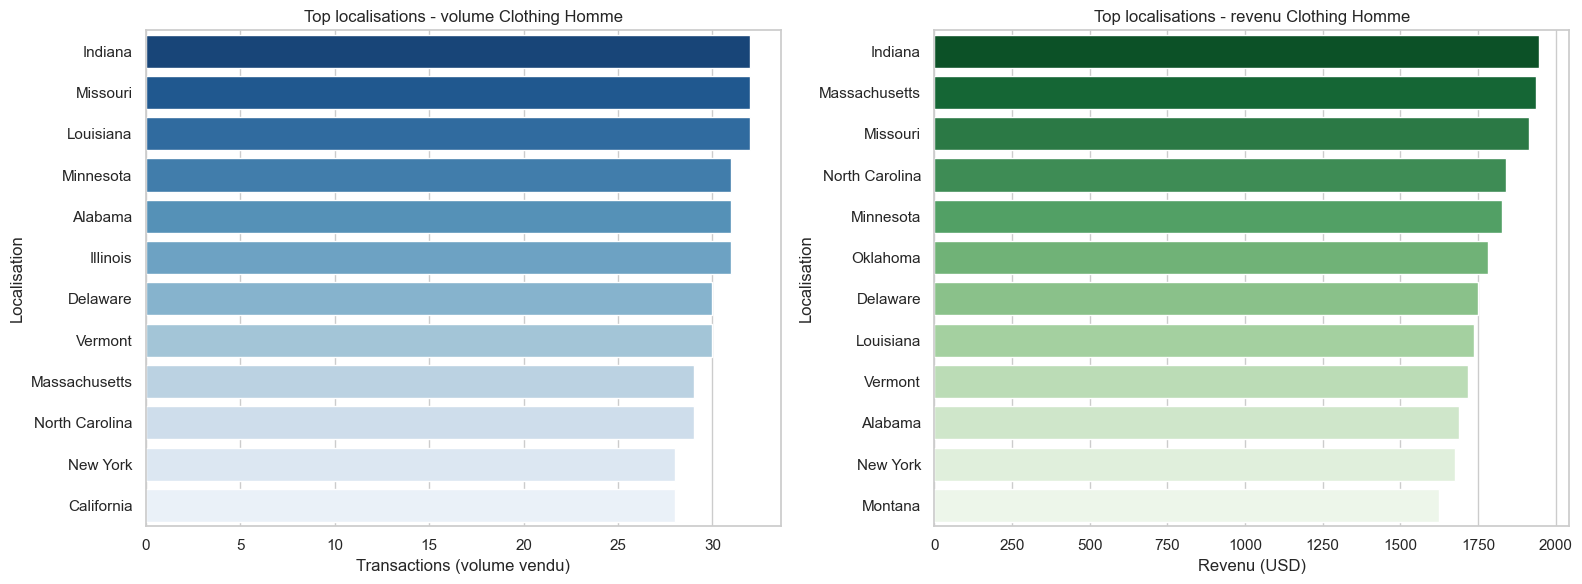

In [23]:
# 1) Volume vendu et revenu par localisation (Homme)
loc_perf = (
    cloth_loc.groupby(location_c, as_index=False)
    .agg(
        transactions=(item_c, "size"),
        revenue=(amount_c, "sum"),
        avg_basket=(amount_c, "mean"),
        unique_customers=(customer_c, "nunique") if customer_c in cloth_loc.columns else (item_c, "size"),
    )
    .sort_values(["transactions", "revenue"], ascending=False)
)

display(loc_perf.head(15).round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=loc_perf.head(12), x="transactions", y=location_c, palette="Blues_r", ax=axes[0])
axes[0].set_title("Top localisations - volume Clothing Homme")
axes[0].set_xlabel("Transactions (volume vendu)")
axes[0].set_ylabel("Localisation")

sns.barplot(data=loc_perf.sort_values("revenue", ascending=False).head(12), x="revenue", y=location_c, palette="Greens_r", ax=axes[1])
axes[1].set_title("Top localisations - revenu Clothing Homme")
axes[1].set_xlabel("Revenu (USD)")
axes[1].set_ylabel("Localisation")

plt.tight_layout()
plt.show()

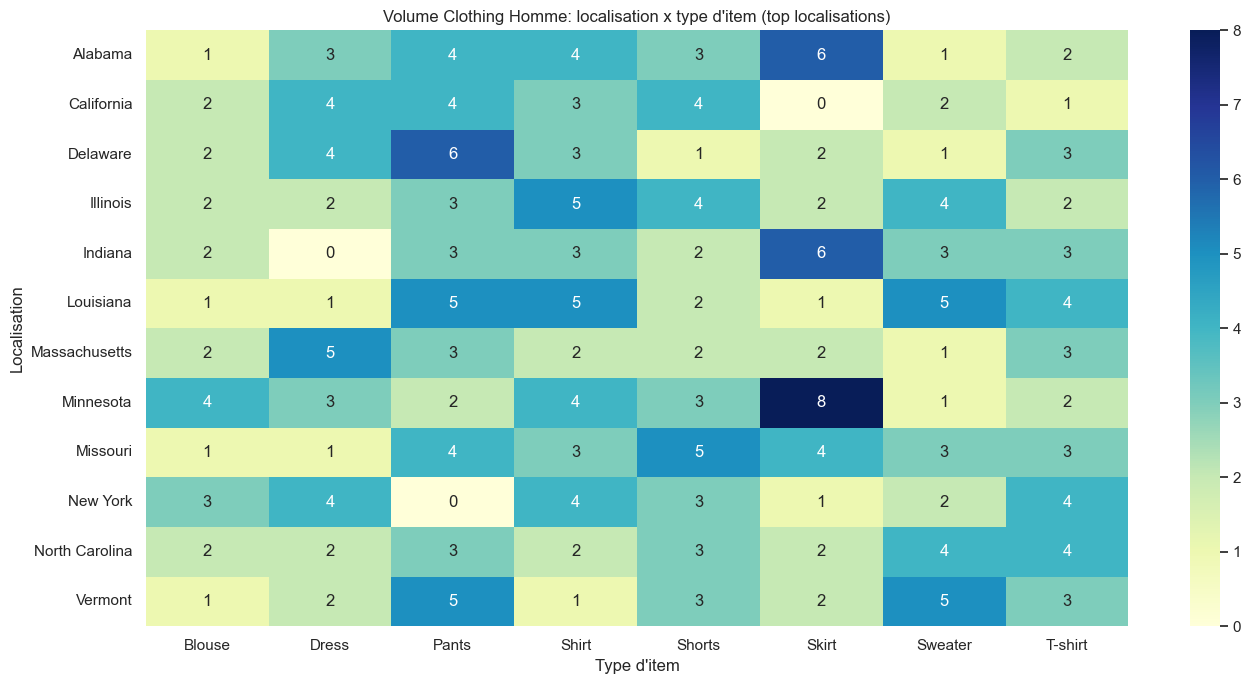

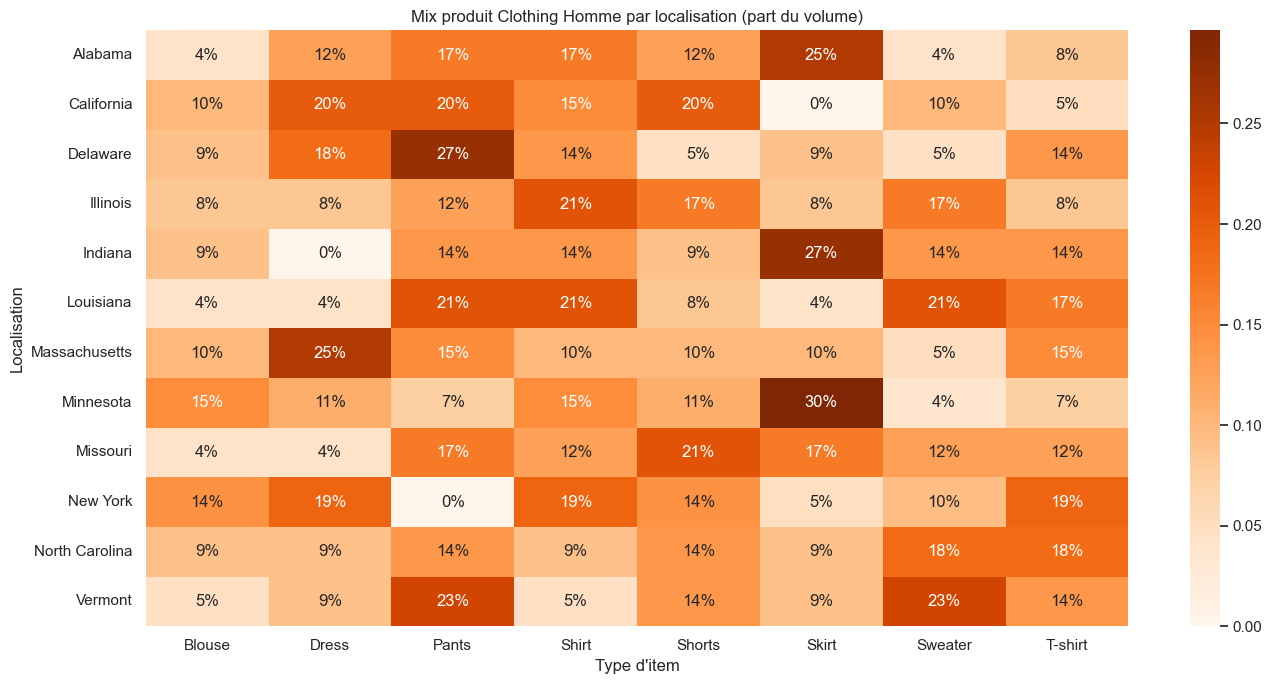

,Location,Item Purchased,transactions,revenue
223,Minnesota,Skirt,8,513
344,Oklahoma,Hoodie,6,420
7,Alabama,Skirt,6,412
72,Delaware,Pants,6,406
91,Georgia,Dress,6,381
482,Wisconsin,T-shirt,6,354
136,Indiana,Skirt,6,315
255,Montana,Sweater,6,292
473,Wisconsin,Blouse,5,423
45,California,Jeans,5,369


In [24]:
# 2) Impact de la localisation sur le type de produit (mix item Homme)
item_loc = (
    cloth_loc.groupby([location_c, item_c], as_index=False)
    .agg(
        transactions=(item_c, "size"),
        revenue=(amount_c, "sum"),
    )
)

# Items les plus populaires chez les hommes pour rester lisible
top_items_global = cloth_loc[item_c].value_counts().head(8).index.tolist()
item_loc_top = item_loc[item_loc[item_c].isin(top_items_global)].copy()

# Heatmap volume: localisation x item
table_vol = item_loc_top.pivot_table(index=location_c, columns=item_c, values="transactions", aggfunc="sum", fill_value=0)

# Garder les localisations les plus actives pour eviter une heatmap trop chargee
top_locs = loc_perf.head(12)[location_c].tolist()
table_vol_plot = table_vol.loc[table_vol.index.intersection(top_locs)]

plt.figure(figsize=(14, 7))
sns.heatmap(table_vol_plot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Volume Clothing Homme: localisation x type d'item (top localisations)")
plt.xlabel("Type d'item")
plt.ylabel("Localisation")
plt.tight_layout()
plt.show()

# Part de mix item par localisation (normalise)
mix_share = table_vol_plot.div(table_vol_plot.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

plt.figure(figsize=(14, 7))
sns.heatmap(mix_share, annot=True, fmt=".0%", cmap="Oranges")
plt.title("Mix produit Clothing Homme par localisation (part du volume)")
plt.xlabel("Type d'item")
plt.ylabel("Localisation")
plt.tight_layout()
plt.show()

display(item_loc.sort_values(["transactions", "revenue"], ascending=False).head(20))

In [25]:
# 3) Synthese automatique: la localisation a-t-elle un impact sur Clothing Homme?
# Mesure simple d'heterogeneite du mix item selon les localisations
# (plus l'ecart type est eleve, plus l'impact localisation est fort)

if len(loc_perf) == 0:
    print("Aucune donnee Clothing Homme disponible.")
else:
    top_location_volume = loc_perf.sort_values("transactions", ascending=False).iloc[0]
    top_location_revenue = loc_perf.sort_values("revenue", ascending=False).iloc[0]

    dominant_item_by_loc = (
        item_loc.sort_values([location_c, "transactions", "revenue"], ascending=[True, False, False])
        .groupby(location_c, as_index=False)
        .first()[[location_c, item_c, "transactions", "revenue"]]
    )

    # Heterogeneite du mix: moyenne des ecarts-types des parts par item
    mix_std_mean = mix_share.std(axis=0).mean() if 'mix_share' in globals() and len(mix_share) > 0 else 0
    if mix_std_mean < 0.03:
        impact_level = "faible"
    elif mix_std_mean < 0.08:
        impact_level = "modere"
    else:
        impact_level = "fort"

    print("=== Synthese Clothing Homme x Localisation ===")
    print(f"Top localisation en volume (Homme): {top_location_volume[location_c]} ({int(top_location_volume['transactions'])} transactions)")
    print(f"Top localisation en revenu (Homme): {top_location_revenue[location_c]} (${top_location_revenue['revenue']:.2f})")
    print(f"Niveau d'impact de la localisation sur le mix produit Homme: {impact_level} (score heterogeneite={mix_std_mean:.3f})")

    print("\nType d'item dominant par localisation (Homme, extrait):")
    display(dominant_item_by_loc.sort_values("transactions", ascending=False).head(12))

    print("\nRecommandation:")
    print("- Prioriser les localisations top volume/revenu chez les hommes pour les lancements.")
    print("- Adapter le mix item Homme localement si l'impact est modere ou fort.")
    print("- Utiliser les localisations les plus performantes chez les hommes comme marche test.")

=== Synthese Clothing Homme x Localisation ===
Top localisation en volume (Homme): Indiana (32 transactions)
Top localisation en revenu (Homme): Indiana ($1946.00)
Niveau d'impact de la localisation sur le mix produit Homme: modere (score heterogeneite=0.061)

Type d'item dominant par localisation (Homme, extrait):


,Location,Item Purchased,transactions,revenue
22,Minnesota,Skirt,8,513
0,Alabama,Skirt,6,412
13,Indiana,Skirt,6,315
7,Delaware,Pants,6,406
25,Montana,Sweater,6,292
9,Georgia,Dress,6,381
35,Oklahoma,Hoodie,6,420
48,Wisconsin,T-shirt,6,354
17,Louisiana,Shirt,5,312
5,Colorado,Pants,5,325



Recommandation:
- Prioriser les localisations top volume/revenu chez les hommes pour les lancements.
- Adapter le mix item Homme localement si l'impact est modere ou fort.
- Utiliser les localisations les plus performantes chez les hommes comme marche test.
